In [88]:
import matplotlib.pyplot as plt
import numpy as np
import qutip as qt

In [125]:
num_qubits = 7
num_levels = 3

annihilation_operators = []
for n in range(num_qubits):
    op_list = [qt.qeye(num_levels)]*num_qubits
    op_list[n] = qt.destroy(num_levels)
    annihilation_operators.append(qt.tensor(op_list))

total_number_operator = sum([a.dag()*a for a in annihilation_operators])


In [126]:
def create_Hamiltonian(annihilation_operators, num_qubits, J, U, phi):
    H = 0

    for i in range(num_qubits):
        a_i = annihilation_operators[i]
        
        H += (U/2) * a_i.dag()*a_i * (a_i.dag()*a_i - 1)
        
        
        a_j = annihilation_operators[(i + 1) % num_qubits]

        coupling = J * np.exp(-1j * phi / num_qubits)
        # print(f'phi: {phi}, coupling: {coupling}')
        # print(coupling * a_i.dag()*a_j + np.conj(coupling) * a_j.dag()*a_i)
        H += coupling * a_i.dag()*a_j + np.conj(coupling) * a_j.dag()*a_i

    return H

In [127]:
J = 10 # MHz
U = 180 # MHz

phases = np.linspace(0, np.pi, 11)

eigenstate_index = 0
num_particles = num_qubits//2
# num_particles = 1

In [128]:
H = create_Hamiltonian(annihilation_operators, num_qubits, J, U, 0)

eigenenergies, eigenstates = H.eigenstates()

    
particle_number_to_eigenenergies = {}
particle_number_to_eigenstates = {}

for energy, state in zip(eigenenergies, eigenstates):
    n = round(qt.expect(total_number_operator, state))
    if n not in particle_number_to_eigenenergies:
        particle_number_to_eigenenergies[n] = []
        particle_number_to_eigenstates[n] = []
    particle_number_to_eigenenergies[n].append(energy)
    particle_number_to_eigenstates[n].append(state)

print(particle_number_to_eigenenergies[num_particles])

[-42.2441258145072, -42.24412581450719, -30.585145527990008, -30.585145527989845, -24.983588097721327, -24.9835880977213, -16.67153184167696, -13.241148302225902, -13.24114830222556, -13.157064315081804, -13.157064315081712, -12.034602094209934, -12.034398859038754, -10.263257576280287, -10.263257576280086, -4.326979227904437, -4.326979227904421, -3.422853107518884, -3.4228531075185344, -0.674600824686754, -0.6746008246863053, 4.179773205476647, 4.1797732054768755, 7.644430706804221, 13.001795561903918, 13.001795561904043, 13.791843105021458, 13.791843105021593, 16.784983182107073, 16.784983182107375, 25.035262386878173, 25.035262386878216, 26.90871477179801, 26.908714771798326, 42.419572305373144, 154.70619320757973, 155.7897717410234, 155.78977174102369, 157.93676612324055, 157.93676612324057, 159.51036525725854, 159.51036525725877, 165.73180730582303, 165.73180730582325, 165.98484789622358, 165.9848478962237, 166.4867431910831, 166.48674319108318, 166.84370202298956, 172.48733814768

In [129]:



phase_to_eigenstate_dict = {}
phase_to_eigenenergy_dict = {}

phase_to_coherences = {}

for i in range(len(phases)):
    phi = phases[i]
    H = create_Hamiltonian(annihilation_operators, num_qubits, J, U, phi)
    eigenenergies, eigenstates = H.eigenstates()

        
    particle_number_to_eigenenergies = {}
    particle_number_to_eigenstates = {}

    for energy, state in zip(eigenenergies, eigenstates):
        n = int(qt.expect(total_number_operator, state))
        if n not in particle_number_to_eigenenergies:
            particle_number_to_eigenenergies[n] = []
            particle_number_to_eigenstates[n] = []
        particle_number_to_eigenenergies[n].append(energy)
        particle_number_to_eigenstates[n].append(state)

    phase_to_eigenstate_dict[phi] = particle_number_to_eigenstates
    phase_to_eigenenergy_dict[phi] = particle_number_to_eigenenergies

    eigenstate = particle_number_to_eigenstates[num_particles][eigenstate_index]

    superfluid_coherences = []

    for i in range(num_qubits):
        a_i = annihilation_operators[i]
        a_j = annihilation_operators[(i + 1) % num_qubits]
        coherence = qt.expect(a_i.dag()*a_j, eigenstate) * J * np.exp(-1j * phi / num_qubits)
        superfluid_coherences.append(coherence)

    phase_to_coherences[phi] = superfluid_coherences
    
    print(f"Phase: {phi}")
    print("superfluid coherences:", superfluid_coherences)
    print()

Phase: 0.0
superfluid coherences: [(-1.982860409092325+0j), (-4.011009817198975+0j), (-2.6930928935462406+0j), (-3.039747722825259+0j), (-3.733014228301153+0j), (-2.137136321835593+0j), (-4.319542437757219+0j)]

Phase: 0.3141592653589793
superfluid coherences: [(-3.056087243041224+1.6364118474567533j), (-3.056087243041278+1.636411847456758j), (-3.056087243041266+1.6364118474567546j), (-3.0560872430412327+1.6364118474567528j), (-3.0560872430413015+1.6364118474567584j), (-3.056087243041207+1.6364118474567535j), (-3.05608724304131+1.6364118474567577j)]

Phase: 0.6283185307179586
superfluid coherences: [(-3.26087559289102-1.2183442295401419j), (-3.2608755928910056-1.2183442295401445j), (-3.2608755928910265-1.218344229540142j), (-3.2608755928910025-1.218344229540146j), (-3.2608755928910247-1.218344229540143j), (-3.260875592891009-1.218344229540145j), (-3.260875592891017-1.2183442295401425j)]

Phase: 0.9424777960769379
superfluid coherences: [(-3.3156582582208274-1.072619615781539j), (-3.315

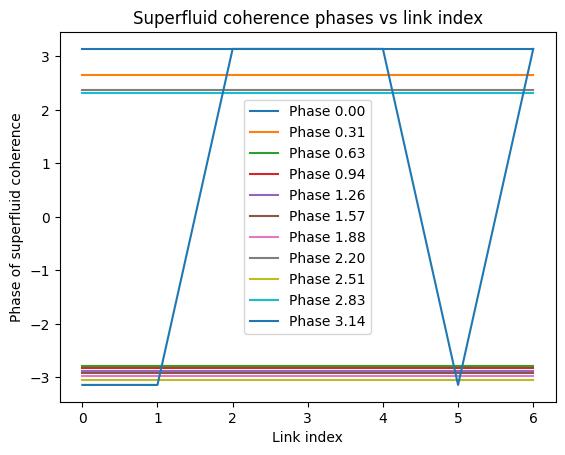

In [132]:
for i in range(len(phases)):
    phi = phases[i]
    superfluid_coherences = phase_to_coherences[phi]
    plt.plot(range(num_qubits), np.angle(superfluid_coherences), label=f"Phase {phi:.2f}")
plt.xlabel("Link index")
plt.ylabel("Phase of superfluid coherence")
plt.title("Superfluid coherence phases vs link index")
plt.legend()
plt.show()

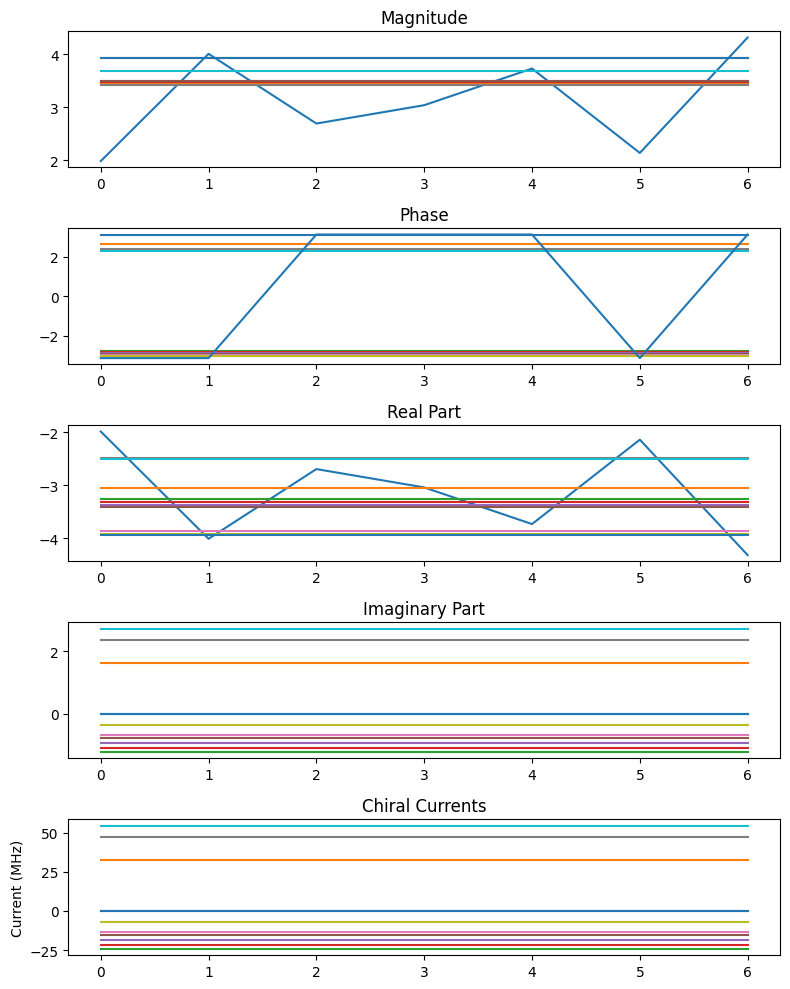

In [133]:
fig, axes = plt.subplots(5, figsize=(8, 10))

for i in range(len(phases)):
    phi = phases[i]
    superfluid_coherences = phase_to_coherences[phi]

    axes[0].plot(range(num_qubits), np.abs(superfluid_coherences), label=f"Phase {phi:.2f}")
    axes[1].plot(range(num_qubits), np.angle(superfluid_coherences), label=f"Phase {phi:.2f}")
    axes[2].plot(range(num_qubits), np.real(superfluid_coherences), label=f"Phase {phi:.2f}")
    axes[3].plot(range(num_qubits), np.imag(superfluid_coherences), label=f"Phase {phi:.2f}")
    
    currents = [2 * J * np.imag(coh) for coh in superfluid_coherences]
    axes[4].plot(range(num_qubits), currents, label=f"Phase {phi:.2f}")

axes[0].set_title("Magnitude")
# axes[0].legend()

axes[1].set_title("Phase")
# axes[1].legend()

axes[2].set_title("Real Part")
# axes[2].legend()

axes[3].set_title("Imaginary Part")
# axes[3].legend()

axes[4].set_ylabel("Current (MHz)")
axes[4].set_title("Chiral Currents")
# axes[4].legend()

plt.tight_layout()
plt.show()

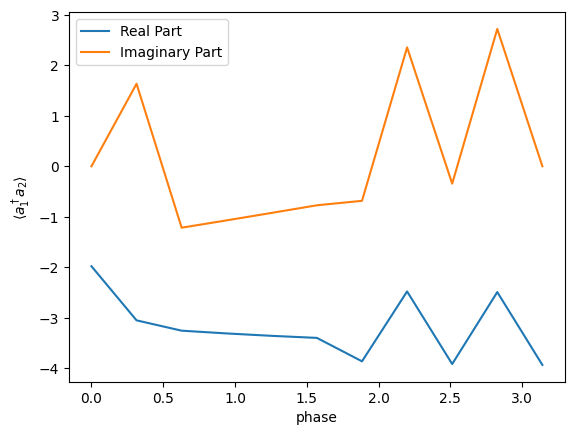

In [134]:
real_parts = [np.real(coherences[0]) for coherences in phase_to_coherences.values()]
imaginary_parts = [np.imag(coherences[0]) for coherences in phase_to_coherences.values()]

plt.plot(phases, real_parts, label="Real Part")
plt.plot(phases, imaginary_parts, label="Imaginary Part")

plt.xlabel("phase")
plt.ylabel("$\langle a_1^\dagger a_2 \\rangle$")

plt.legend()